# M2b: FM100 vs. EEG -- extending the severity spectrum test

`PLANssvep_bh_fm100.md` M2: the same two pre-specified tests M1 ran
against behavioral data, now against EEG. One added insight motivating the
feature split: `ramp_slope_red` and `ramp_slope_green` together form a 2D
vector in the same "which way does the deficiency point" family as
`VKS_Angle` and `orientation_deg`, not just a severity measure --
`eeg_features.py` splits it accordingly:

1. **Severity** -- CCA between FM100 (`TES`, `VKS_MajRad`, `VKS_MinRad`)
   and EEG (`ramp_magnitude`, `ramp_intercept` -- deliberately excluding
   the raw slopes, which now feed the type/axis test instead).
2. **Type/axis** -- circular correlation between `VKS_Angle` and the EEG
   ramp-vector's angle (folded to axial `[0, 180)` for this comparison --
   see `eeg_features.py`'s module docstring for why that's a deliberate
   simplification, not a claim the sign never matters).

`severity.py`/`type_axis.py` are reused completely unchanged from M1 --
the whole point of building them feature-set-agnostic. Both EEG features'
reliability is moderate, not strong (`03_eeg_reliability.ipynb`) -- carried
forward as a caveat, same posture M1 took with `VKS_Angle`.

In [1]:
import sys
sys.path.append('../scripts')

import fm100_features
import eeg_features

# fm100_features's own import inserts ssveps/scripts at sys.path[0] (it
# needs ssveps' reliability.py) -- ssveps/scripts has its own plotting.py
# too, so re-assert this project's scripts/ first before resolving
# "plotting", or it would silently import ssveps' version instead.
sys.path.insert(0, '../scripts')
import plotting
import severity
import type_axis

import matplotlib.pyplot as plt
import pandas as pd

fm100_df = fm100_features.fm100_loader.load_fm100_raw()
fm100_pooled = fm100_features.subject_pooled_features(fm100_df)

troughs = eeg_features.load_subject_troughs()
eeg_session1 = eeg_features.subject_session_features(troughs)
eeg_session1 = eeg_session1[eeg_session1['session'] == 1]

merged = fm100_pooled.merge(eeg_session1, on='sub_id', suffixes=('_fm100', '_eeg'))
print(f"{len(merged)} subjects with both FM100 and EEG (session 1) data")
merged.groupby(['group_eeg', 'subgroup_eeg'])['sub_id'].nunique()

43 subjects with both FM100 and EEG (session 1) data


group_eeg  subgroup_eeg
CVD        deutan          7
           protan          8
Name: sub_id, dtype: int64

## Test 1: severity (CCA)

In [2]:
SEVERITY_FM100 = ['TES', 'VKS_MajRad', 'VKS_MinRad']
SEVERITY_EEG = ['ramp_magnitude', 'ramp_intercept']

X_all = merged[SEVERITY_FM100].to_numpy()
Y_all = merged[SEVERITY_EEG].to_numpy()
severity_result = severity.cca_test(X_all, Y_all, n_perm=5000, seed=0)
print(f"r={severity_result['r']:.3f}, p={severity_result['p_value']:.4f}, n={len(merged)}")

r=0.502, p=0.0466, n=43


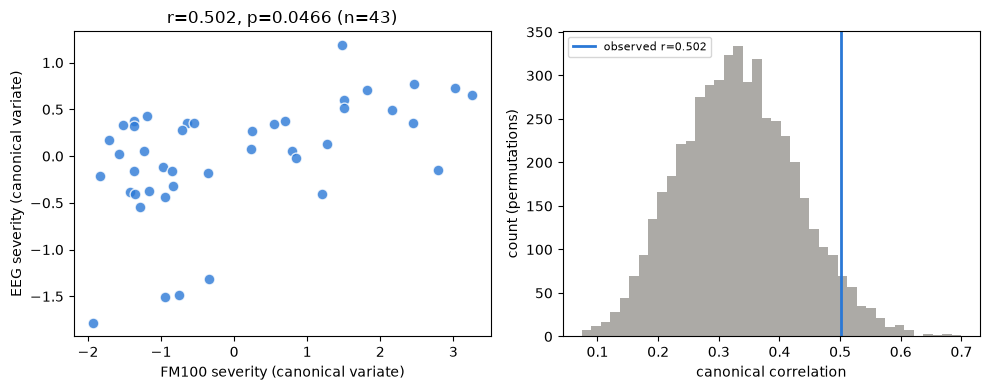

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plotting.plot_canonical_variates(severity_result, x_label='FM100 severity (canonical variate)', y_label='EEG severity (canonical variate)', ax=axes[0])
plotting.plot_null_distribution(severity_result, ax=axes[1])
fig.tight_layout()

**Pooled, significant but more modest than the behavioral version** (r=0.50,
p=0.047, vs. M1's r=0.73, p<0.001) -- consistent with EEG being the
noisier, more indirect measure throughout this project.

In [4]:
categories = [
    ('all', merged),
    ('HC', merged[merged.group_eeg == 'CTR']),
    ('PD', merged[merged.group_eeg == 'PD']),
    ('CVD', merged[merged.group_eeg == 'CVD']),
    ('protan', merged[merged.subgroup_eeg == 'protan']),
    ('deutan', merged[merged.subgroup_eeg == 'deutan']),
]

rows = []
for label, sub in categories:
    if len(sub) < 3:
        rows.append({'category': label, 'n': len(sub), 'r': None, 'p_value': None})
        continue
    r = severity.cca_test(sub[SEVERITY_FM100].to_numpy(), sub[SEVERITY_EEG].to_numpy(), n_perm=2000, seed=0)
    rows.append({'category': label, 'n': len(sub), 'r': r['r'], 'p_value': r['p_value']})
severity_by_group = pd.DataFrame(rows)
severity_by_group

,category,n,r,p_value
0,all,43,0.502047,0.039980
1,HC,21,0.344165,0.853073
2,PD,6,0.849318,0.853573
3,CVD,15,0.588376,0.460770
4,protan,8,0.669439,0.835582
5,deutan,7,0.983886,0.095452


**Same pattern as M1: only the pooled result is significant.** No single
group reaches significance on its own -- likely, as in M1, at least partly
a between-group effect rather than a confirmed within-group continuum, and
here further diluted by EEG's own noisier measurement.

## Test 2: type/axis (circular correlation)

In [5]:
type_result = type_axis.circular_correlation_test(merged['VKS_Angle'].to_numpy(), merged['ramp_angle_deg'].to_numpy())
print(type_result)

{'r': -0.398173813981156, 'p_value': 0.013744800587652402, 'n': 43}


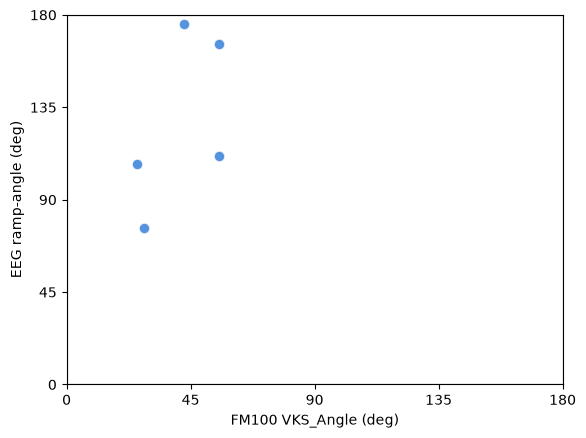

In [6]:
plotting.plot_circular_scatter(merged['VKS_Angle'].to_numpy(), merged['ramp_angle_deg'].to_numpy(), x_label='FM100 VKS_Angle (deg)', y_label='EEG ramp-angle (deg)');

In [7]:
rows = []
for label, sub in categories:
    if len(sub) < 3:
        rows.append({'category': label, 'n': len(sub), 'r': None, 'p_value': None})
        continue
    t = type_axis.circular_correlation_test(sub['VKS_Angle'].to_numpy(), sub['ramp_angle_deg'].to_numpy())
    rows.append({'category': label, 'n': len(sub), 'r': t['r'], 'p_value': t['p_value']})
type_by_group = pd.DataFrame(rows)
type_by_group

,category,n,r,p_value
0,all,43,-0.398174,0.013745
1,HC,21,0.001946,0.993279
2,PD,6,0.631367,0.088378
3,CVD,15,0.004435,0.986272
4,protan,8,-0.544292,0.124837
5,deutan,7,0.661403,0.034124


**Pooled: significant** (r=-0.40, p=0.014 -- the negative sign isn't
directly comparable to M1's positive r for FM100-vs-behavioral; each pair
of angle spaces has its own coordinate convention, so sign alone isn't
evidence of anything contradictory). Per-group: CTR and CVD (combined) are
both essentially at r=0 -- no relationship at all in either. **`deutan`
alone is significant** (r=0.66, p=0.034, n=7) -- but at n=7 this is thin
enough to treat as a lead worth re-testing with more deutan subjects, not
a confirmed within-subtype finding the way M1's within-CVD result (n=15)
was. protan (n=8) trends negative but doesn't reach significance
(p=0.125).

## Context table (not a significance claim)

In [8]:
import pingouin as pg

fm100_feats = ['TES', 'VKS_Angle', 'VKS_MajRad', 'VKS_MinRad']
eeg_feats = ['ramp_magnitude', 'ramp_angle_deg', 'ramp_intercept', 'ramp_r_squared']

context_rows = []
for ff in fm100_feats:
    for ef in eeg_feats:
        result = pg.corr(merged[ff], merged[ef], method='spearman')
        context_rows.append({'fm100_feature': ff, 'eeg_feature': ef, 'r': result['r'].iloc[0], 'p_value': result['p_val'].iloc[0], 'n': int(result['n'].iloc[0])})
context_table = pd.DataFrame(context_rows)
context_table.sort_values('p_value').head(10)

,fm100_feature,eeg_feature,r,p_value,n
9,VKS_MajRad,ramp_angle_deg,0.440501,0.003114,43
13,VKS_MinRad,ramp_angle_deg,0.437934,0.003314,43
1,TES,ramp_angle_deg,0.433998,0.003642,43
10,VKS_MajRad,ramp_intercept,-0.408638,0.006517,43
2,TES,ramp_intercept,-0.395937,0.008584,43
14,VKS_MinRad,ramp_intercept,-0.388100,0.010122,43
11,VKS_MajRad,ramp_r_squared,-0.321504,0.035528,43
3,TES,ramp_r_squared,-0.305014,0.046718,43
15,VKS_MinRad,ramp_r_squared,-0.292510,0.056981,43
7,VKS_Angle,ramp_r_squared,0.187859,0.227683,43


## Summary

- **Severity**: significant pooled (r=0.50, p=0.047) but more modest than
  the behavioral version (r=0.73), and doesn't hold up within any single
  group -- same "likely partly between-group" caveat as M1, compounded by
  EEG's noisier measurement.
- **Type/axis**: significant pooled (r=-0.40, p=0.014); within-group,
  only `deutan` reaches significance (r=0.66, p=0.034), and at n=7 that's
  a lead, not a confirmed finding -- unlike M1's more robust within-CVD
  result (n=15).
- **Both EEG severity and type/axis results are weaker than their
  behavioral counterparts** -- consistent with everything else in this
  project: EEG is a real but noisier window onto the same underlying
  severity spectrum than direct behavioral report is. The clearest,
  most solid result across all of M1+M2 remains M1's within-CVD
  `VKS_Angle`-vs-`orientation_deg` finding (n=15, p=0.031).
- Next: more CVD/protan/deutan subjects (the standing recommendation
  throughout this whole project) would do more for this analysis than any
  further methodological refinement at this point.